In [6]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Path to your database
# Adjust the path if your notebook is in the 'notebooks' folder
DB_PATH = os.path.join('..', 'data', 'maintenance.db')

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM sensor_logs", conn)
conn.close()

print(f"Data Loaded: {df.shape[0]} rows")
df.head()

Data Loaded: 48 rows


,timestamp,machine_id,temperature,vibration,pressure,target
0,2026-03-12T08:00:00,M_001,70.2,15.1,100.5,0
1,2026-03-12T08:30:00,M_001,71.5,14.8,101.2,0
2,2026-03-12T09:00:00,M_001,72.1,15.5,99.8,0
3,2026-03-12T09:30:00,M_001,78.5,18.2,105.4,1
4,2026-03-12T10:00:00,M_001,77.9,19.5,103.1,1


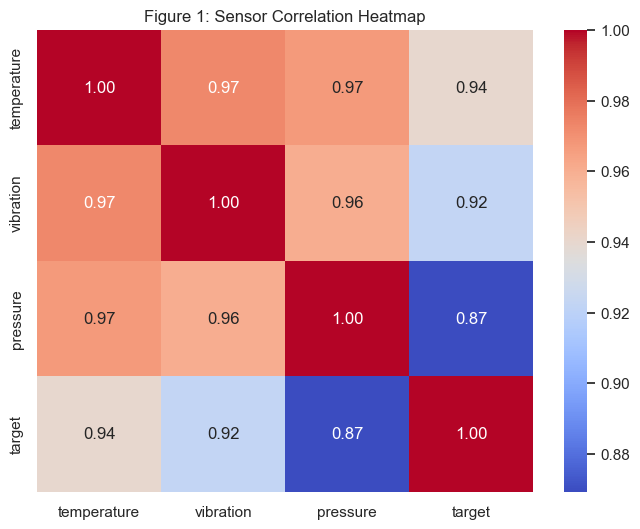

In [7]:
plt.figure(figsize=(8, 6))
# Remove non-numeric columns for correlation
numeric_df = df.drop(columns=['timestamp', 'machine_id'])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Figure 1: Sensor Correlation Heatmap")
plt.show()

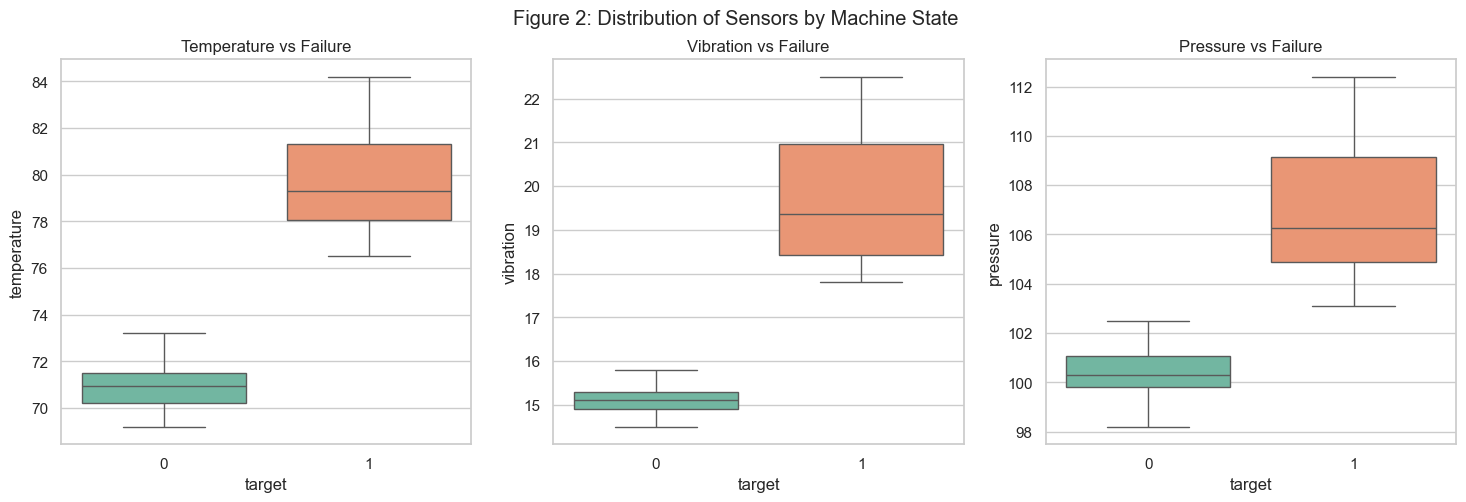

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: Temperature
sns.boxplot(x='target', y='temperature', data=df, ax=axes[0],
            hue='target', palette='Set2', legend=False)
axes[0].set_title('Temperature vs Failure')

# Subplot 2: Vibration
sns.boxplot(x='target', y='vibration', data=df, ax=axes[1],
            hue='target', palette='Set2', legend=False)
axes[1].set_title('Vibration vs Failure')

# Subplot 3: Pressure
sns.boxplot(x='target', y='pressure', data=df, ax=axes[2],
            hue='target', palette='Set2', legend=False)
axes[2].set_title('Pressure vs Failure')

plt.suptitle("Figure 2: Distribution of Sensors by Machine State")
plt.show()

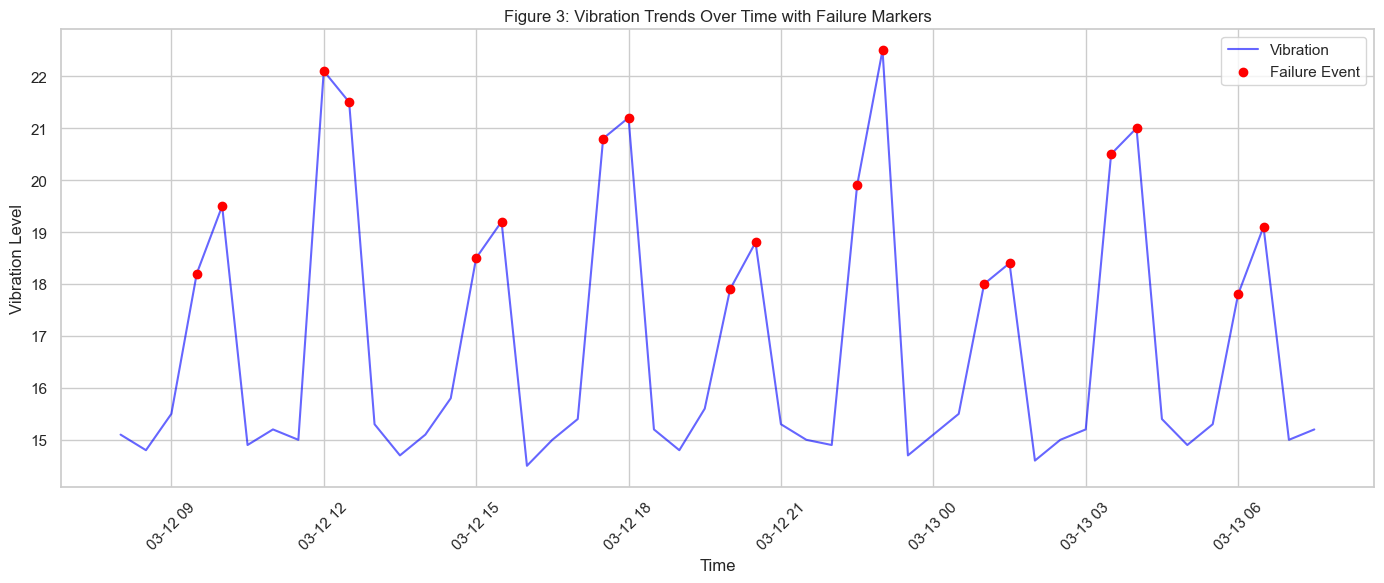

In [9]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

plt.figure(figsize=(14, 6))
plt.plot(df['timestamp'], df['vibration'], label='Vibration', color='blue', alpha=0.6)

# Highlight failures
failures = df[df['target'] == 1]
plt.scatter(failures['timestamp'], failures['vibration'], color='red', label='Failure Event', zorder=5)

plt.title("Figure 3: Vibration Trends Over Time with Failure Markers")
plt.xlabel("Time")
plt.ylabel("Vibration Level")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()